# Experiment 3: Stochastic Training and Temporal Robustness

Evaluates whether training on stochastically corrupted TEMPO v1.1 data produces
SNNs that generalise to unseen noise levels, compared to training on deterministic
(ideal) Morse timing.

## Training conditions

| | Model D (deterministic) | Model S (stochastic) |
|---|---|---|
| **Training σ** | 0 (ideal timing) | 0.838 × T_u (TEMPO protocol) |
| **Training ω** | 1.0 (fixed) | U[0.8, 1.3] (random per word) |
| **Training r** | 3.0 (fixed) | U[2.5, 4.5] (random per word) |
| **Samples / class** | 500 | 500 |

## Run History

| Run | Architecture | Config | D@σ=0 | S@σ=0 | Crossover |
|-----|-------------|--------|:------:|:------:|:---------:|
| Run 1 (aborted) | Multi-Timescale LIF SNN | BS=1024, BF16, dual-GPU threads | 37.8% | 66.1% | N/A (D failed to converge: 52.9% train acc) |
| Run 2 *(3 seeds)* | Multi-Timescale LIF SNN | BS=256, BF16, dual-GPU threads | 97.9%±0.6 | 98.7%±0.7 | S leads at all σ (confound: stochastic ω/r at all test points puts D out-of-distribution) |
| **Run 3** *(pending)* | **Multi-Timescale LIF SNN** | **BS=256, BF16, 3×GPU pool; adds fixed-ω/r crossover ablation** | — | — | **Expected: crossover near σ ≈ 0.42 in ablation** |

---

## Evaluation

Two parallel test sweeps across σ_test ∈ {0.00, 0.20, 0.40, 0.60, 0.84, 1.00, 1.20} × T_u:

| Test condition | ω | r | Purpose |
|---|---|---|---|
| **Main** | U[0.8, 1.3] | U[2.5, 4.5] | Practical deployment: all corruption layers active |
| **Crossover ablation** | 1.0 (fixed) | 3.0 (fixed) | Isolates jitter: D is within its training distribution at σ=0 |

Each test set: 100 samples per class (2,600 total). Main and ablation test sets
use independent RNG seeds to ensure no correlation.

## Success Criteria

| Criterion | Target | Rationale |
|-----------|--------|-----------|
| Model D train accuracy | ≥ 90% | Ideal Morse is easy; model should converge cleanly |
| Model S test acc at σ=0.84 (main) | ≥ 65% | Matches training conditions (cf. Exp2 intact ~73%) |
| Crossover exists (ablation) | σ_cross ≤ 1.20 × T_u | With ω/r fixed, D is in-distribution at σ=0; crossover should appear |
| Model S at σ=1.20 | > chance (3.85%) | Graceful degradation beyond training distribution |
| Model D at σ=1.20 | < Model S | D degrades faster than S at extreme noise |

## Expected outcome

- **Main test (stochastic ω, r)**: Model S leads at all or most noise levels —
  stochastic training is beneficial broadly.
- **Ablation (fixed ω=1.0, r=3.0)**: Model D leads at low σ (within its training
  distribution); crossover near σ ≈ 0.42 × T_u; Model S leads above crossover.
  This cleanly isolates the jitter-training contribution.

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import threading
import contextlib
from torch.utils.data import DataLoader, TensorDataset

try:
    import snntorch as snn
    from snntorch import surrogate
    print(f'snnTorch {snn.__version__}')
except ImportError:
    print('snnTorch not found.  Install with:  pip install snntorch')
    raise

# Import TEMPO encoder (project root must be on sys.path)
try:
    from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE
except ImportError:
    sys.path.insert(0, os.path.abspath('..'))
    from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Default device (overridden by the CUDA setup cell below) ───────────────
FORCE_CPU = False
if FORCE_CPU:
    device = torch.device('cpu')
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device : {device}')
print(f'NumPy  {np.__version__},  PyTorch {torch.__version__},  seed={SEED}')

snnTorch 0.9.4


Device : cuda
NumPy  1.26.3,  PyTorch 2.7.1+cu128,  seed=42


In [2]:
# ── Transmission ──────────────────────────────────────────────────────────
WPM = 20
T_U = 1200.0 / WPM                   # 60 ms at 20 WPM

# ── TEMPO v1.1 protocol ───────────────────────────────────────────────────
SIGMA_FRAC_TRAIN = 0.838             # Model S jitter: sigma = 0.838 * T_u
T_THRESH_FRAC    = 2.17              # channel decision boundary (x T_u)
OMEGA_LO, OMEGA_HI = 0.8, 1.3
R_LO,     R_HI     = 2.5, 4.5
MAX_T = 1600                         # fixed time axis (ms bins)

# ── Dataset ───────────────────────────────────────────────────────────────
LETTERS   = sorted(k for k in MORSE_TABLE if k.isalpha())
N_CLASSES = len(LETTERS)             # 26
N_TRAIN   = 500                      # training samples per class
N_TEST    = 100                      # test samples per class per sigma level

# ── Training ──────────────────────────────────────────────────────────────
N_EPOCHS  = 100
# Reverted from 1024 back to 256 (matching Exp2).  Run 1 with BS=1024 reduced
# gradient updates from 5,100 (Exp2) to 1,300 per 100 epochs, causing severe
# under-convergence (Model D: 52.9% vs expected ≥90%).  The TempoSNN is
# 3.7k parameters with a 2-channel input — matmuls are compute-trivial and
# do not benefit from large batches on the L40S.
BATCH_SIZE = 256
N_SEEDS    = 10

# Quick-run flag (reduce for debugging before a full run)
QUICK_RUN = False
if QUICK_RUN:
    N_EPOCHS = 10
    N_SEEDS  = 1
    N_TRAIN  = 50
    N_TEST   = 20
    print('QUICK_RUN enabled: N_EPOCHS=10, N_SEEDS=1, N_TRAIN=50, N_TEST=20')

# ── Experiment 3: test noise sweep ────────────────────────────────────────
SIGMA_TEST_FRACS = [0.00, 0.20, 0.40, 0.60, 0.84, 1.00, 1.20]  # x T_u
SIGMA_TEST_ABS   = [f * T_U for f in SIGMA_TEST_FRACS]           # ms

print(f'T_u        = {T_U:.0f} ms')
print(f'Letters    : {" ".join(LETTERS)}')
print(f'Max T      : {MAX_T} ms bins')
print(f'Train      : {N_CLASSES} x {N_TRAIN} = {N_CLASSES*N_TRAIN} samples per model')
print(f'Test       : {N_CLASSES} x {N_TEST}  = {N_CLASSES*N_TEST} samples per sigma level')
print(f'Epochs     : {N_EPOCHS}  (cosine LR: 5e-4 -> 1e-5)')
print(f'Batch size : {BATCH_SIZE}')
print(f'Seeds      : {N_SEEDS}')
print()
print(f'Model D: sigma=0, omega=1.0, r=3.0  (deterministic ideal Morse)')
print(f'Model S: sigma={SIGMA_FRAC_TRAIN}*T_u, omega~U[{OMEGA_LO},{OMEGA_HI}], r~U[{R_LO},{R_HI}]')
print()
print(f'Test sigma levels (x T_u): {SIGMA_TEST_FRACS}')

T_u        = 60 ms
Letters    : A B C D E F G H I J K L M N O P Q R S T U V W X Y Z
Max T      : 1600 ms bins
Train      : 26 x 500 = 13000 samples per model
Test       : 26 x 100  = 2600 samples per sigma level
Epochs     : 100  (cosine LR: 5e-4 -> 1e-5)
Batch size : 256
Seeds      : 10

Model D: sigma=0, omega=1.0, r=3.0  (deterministic ideal Morse)
Model S: sigma=0.838*T_u, omega~U[0.8,1.3], r~U[2.5,4.5]

Test sigma levels (x T_u): [0.0, 0.2, 0.4, 0.6, 0.84, 1.0, 1.2]


In [3]:
# ── CUDA environment check ────────────────────────────────────────────────
N_CUDA_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f'CUDA GPUs detected: {N_CUDA_GPUS}')
for i in range(N_CUDA_GPUS):
    props = torch.cuda.get_device_properties(i)
    gb    = props.total_memory / 1024**3
    bf16  = props.major >= 8
    print(f'  cuda:{i}  {props.name}  {gb:.0f} GB  '
          f'cc={props.major}.{props.minor}  BF16={bf16}  SMs={props.multi_processor_count}')

# ── Multi-GPU strategy ───────────────────────────────────────────────────
# With N_CUDA_GPUS workers and 2*N_SEEDS training tasks (N_SEEDS D-models +
# N_SEEDS S-models), all GPUs stay busy: tasks are dispatched from a shared
# queue and each worker grabs any available GPU.  This decouples D and S
# training — they no longer need to be paired on the same two GPUs, allowing
# all N_CUDA_GPUS GPUs to run concurrently.
#
# Example with 3 GPUs, 10 seeds: 20 tasks dispatched to 3 workers = ~7 rounds
# vs the previous 2-GPU paired approach (10 sequential rounds).  ~30% faster.
N_GPU_WORKERS = max(N_CUDA_GPUS, 1)

USE_AMP     = N_CUDA_GPUS >= 1   # BF16 autocast on L40S tensor cores
USE_COMPILE = False               # torch.compile (enable for long production runs)

device_0 = torch.device('cuda:0') if N_CUDA_GPUS >= 1 else torch.device('cpu')
device   = device_0               # keep 'device' alias for backward compat

print()
print(f'N_GPU_WORKERS : {N_GPU_WORKERS}  ({N_CUDA_GPUS} GPUs, task-based pool)')
print(f'USE_AMP       : {USE_AMP}       (BF16 autocast)')
print(f'USE_COMPILE   : {USE_COMPILE}')

CUDA GPUs detected: 3
  cuda:0  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142
  cuda:1  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142
  cuda:2  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142

N_GPU_WORKERS : 3  (3 GPUs, task-based pool)
USE_AMP       : True       (BF16 autocast)
USE_COMPILE   : False


## Custom Encoder for Variable Jitter

The TEMPO encoder (`encode_word`) accepts `jitter=True/False` and
hardcodes σ = 0.838 × T_u.  Experiment 3 requires generating test sets
at 7 different σ levels, so we need a local version that accepts σ
as a direct parameter.

`encode_word_sigma` replicates Algorithm 1 (TEMPO v1.1) exactly but:
1. Accepts σ in ms directly (use σ = 0.0 for jitter-free encoding).
2. **Always** samples ω and r stochastically — matching the paper's
   specification that all test conditions use stochastic ω and r.

In [4]:
def encode_word_sigma(word, t_u, sigma, rng=None, omega=None, r=None):
    '''Encode a word with specific jitter sigma (ms) and configurable omega, r.

    Identical internal algorithm to encode_word() from
    tempo.dataset.generate_dataset, but sigma is a direct parameter
    (in ms) rather than a boolean jitter flag.

    Args:
        word:  Uppercase string to encode.
        t_u:   Base time unit (ms).
        sigma: Jitter standard deviation (ms). 0.0 = no Gaussian jitter.
        rng:   numpy RandomGenerator.
        omega: Word-level timing multiplier. If None, sampled from U[0.8, 1.3]
               (stochastic, matching main test conditions). Pass a float to fix
               (e.g. omega=1.0 for the crossover ablation).
        r:     Dash-to-dot duration ratio. If None, sampled from U[2.5, 4.5].
               Pass a float to fix (e.g. r=3.0 for the crossover ablation).

    Returns:
        List of (timestamp_ms, channel) tuples; channel 0=dot, 1=dash.
    '''
    if rng is None:
        rng = np.random.default_rng()

    t_thresh = 2.17 * t_u
    _omega   = rng.uniform(OMEGA_LO, OMEGA_HI) if omega is None else omega
    _r       = rng.uniform(R_LO,     R_HI)     if r     is None else r

    t_current = 0.0
    spikes    = []
    chars     = [c for c in word if c in MORSE_TABLE]

    for ci, char in enumerate(chars):
        pattern = MORSE_TABLE[char]

        for ei, element in enumerate(pattern):
            # Mark duration
            t_ideal    = (1.0 if element == '.' else _r) * t_u
            t_weighted = t_ideal * _omega
            t_noisy    = t_weighted + rng.normal(0, sigma) if sigma > 0 else t_weighted
            t_final    = max(t_noisy, 0.1 * t_u)

            t_spike = t_current + t_final
            channel = 0 if t_final < t_thresh else 1
            spikes.append((t_spike, channel))

            # Intra-character gap (after every element)
            gap_ideal  = 1.0 * t_u
            gap_noisy  = gap_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
            gap_final  = max(gap_noisy, 0.1 * t_u)
            t_current  = t_spike + gap_final

        # Inter-character gap (supersedes last intra-char gap)
        t_current  = spikes[-1][0]
        gap_ideal  = 3.0 * t_u
        gap_noisy  = gap_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
        gap_final  = max(gap_noisy, 0.1 * t_u)
        t_current += gap_final

    # Inter-word gap at end (supersedes last inter-character gap)
    if spikes:
        t_current  = spikes[-1][0]
        gap_ideal  = 7.0 * t_u
        gap_noisy  = gap_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
        gap_final  = max(gap_noisy, 0.1 * t_u)
        t_current += gap_final

    return spikes


def make_spike_tensor(spikes, max_t):
    '''Convert [(timestamp_ms, channel)] -> binary tensor [max_t, 2].'''
    tensor = np.zeros((max_t, 2), dtype=np.float32)
    for t, ch in spikes:
        idx = int(round(t))
        if 0 <= idx < max_t:
            tensor[idx, ch] = 1.0
    return tensor


# ── Sanity checks ─────────────────────────────────────────────────────────
_rng1 = np.random.default_rng(0)
_rng2 = np.random.default_rng(0)
_s1 = encode_word('A', T_U, weighting=True, dash_ratio=True, jitter=True, rng=_rng1)
_s2 = encode_word_sigma('A', T_U, sigma=SIGMA_FRAC_TRAIN * T_U, rng=_rng2)
assert _s1 == _s2, f'Mismatch: {_s1} vs {_s2}'
print('encode_word_sigma matches encode_word (jitter=True) for same seed.')

# sigma=0: no jitter, omega and r still stochastic
_s3 = encode_word_sigma('E', T_U, sigma=0.0, rng=np.random.default_rng(1))
print(f'E at sigma=0 (stochastic omega/r): {_s3}')

# fixed omega/r: deterministic baseline (crossover ablation)
_s4 = encode_word_sigma('E', T_U, sigma=0.0, rng=np.random.default_rng(1),
                         omega=1.0, r=3.0)
print(f'E at sigma=0 (fixed omega=1.0, r=3.0): {_s4}')

encode_word_sigma matches encode_word (jitter=True) for same seed.
E at sigma=0 (stochastic omega/r): [(63.35464874100771, 0)]
E at sigma=0 (fixed omega=1.0, r=3.0): [(60.0, 0)]


## Data Generation

Three data generation functions:

- **`generate_train_split`**: Training data for either model.  
  `deterministic=True` → ideal Morse (σ=0, ω=1.0, r=3.0, Model D);  
  `deterministic=False` → full TEMPO v1.1 (σ=0.838×T_u, ω~U, r~U, Model S).
- **`generate_test_split`**: Main test data at a specified σ level.  
  Always uses stochastic ω and r; only σ varies across the seven test points.
- **`generate_test_split_fixed`**: Crossover ablation test data at a specified σ level.  
  Uses fixed ω=1.0, r=3.0; only σ varies. Places Model D within its training
  distribution at σ_test=0, revealing the clean jitter-training crossover.

Each seed uses independent RNGs for Model D training, Model S training, and each
test set (main and ablation), ensuring no correlation between splits.

In [5]:
def generate_train_split(letters, n_per_class, t_u, max_t, deterministic, rng, label=''):
    '''Generate training data for Model D (deterministic) or Model S (stochastic).

    deterministic=True  -> encode_word(jitter=False, weighting=False, dash_ratio=False)
                           sigma=0, omega=1.0, r=3.0 (ideal Morse)
    deterministic=False -> encode_word(jitter=True,  weighting=True,  dash_ratio=True)
                           sigma=0.838*T_u, omega~U, r~U (TEMPO v1.1)
    '''
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word(
                letter, t_u,
                weighting  = not deterministic,
                dash_ratio = not deterministic,
                jitter     = not deterministic,
                rng        = rng,
            )
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)  # [N, T, 2]
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


def generate_test_split(letters, n_per_class, t_u, max_t, sigma_abs, rng, label=''):
    '''Generate main test data at specified sigma (ms) with stochastic omega and r.

    sigma_abs=0.0 -> no Gaussian jitter, but omega and r are still stochastic.
    Matches the paper: "with omega and r sampled stochastically for all
    test conditions".
    '''
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma_abs, rng=rng)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


def generate_test_split_fixed(letters, n_per_class, t_u, max_t, sigma_abs, rng, label=''):
    '''Generate crossover ablation test data: fixed omega=1.0, r=3.0, varying sigma.

    Holds omega and r at nominal ITU values so that Model D (trained on ideal
    Morse with omega=1.0, r=3.0) is within its training distribution at
    sigma_test=0. This reveals the clean crossover where stochastic jitter
    training (Model S) takes over from deterministic training (Model D).
    '''
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma_abs, rng=rng,
                                       omega=1.0, r=3.0)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y

## SNN Architecture — Multi-Timescale LIF SNN (same as Experiment 2)

Both Model D and Model S use the identical TempoSNN architecture validated
in Experiment 2.  The multi-timescale design is important here: Model D's
ideal training data converges easily, while Model S needs the slow group
(τ ≈ 500 ms) to bridge full letter durations under high corruption.

| Group | Neurons | β | τ (ms) | Role |
|-------|--------:|----:|-------:|------|
| Fast  | 42 | 0.95 | ~20 | Local mark detection |
| Medium | 43 | 0.99 | ~100 | Intra-character context |
| Slow  | 43 | 0.998 | ~500 | Full-letter integration |

All groups use soft reset (`reset_mechanism='subtract'`) to preserve
inter-mark membrane state.  All β are learnable.

**Note on training time**: training 6 models (2 × 3 seeds) is approximately
twice the compute of Experiment 2.  Use `QUICK_RUN=True` above for a fast
sanity check before committing to the full run.

In [6]:
spike_grad = surrogate.fast_sigmoid()


class TempoSNN(nn.Module):
    '''Multi-Timescale LIF SNN with soft reset.

    Identical architecture to Experiment 2.  Three neuron groups share
    a single fc1 but use different membrane decay constants, giving the
    network access to fast (~20 ms), medium (~100 ms), and slow (~500 ms)
    temporal scales simultaneously.

    Performance optimization: fc1 and fc2 are batched across all T time
    steps in a single matmul (see Exp2 notebook for details).
    '''

    # (n_neurons, beta, threshold)
    GROUPS = [
        (42,  0.95,  0.3),    # fast:   tau ~  20 ms  -- local mark detection
        (43,  0.99,  0.4),    # medium: tau ~ 100 ms  -- intra-character context
        (43,  0.998, 0.5),    # slow:   tau ~ 500 ms  -- full-letter integration
    ]

    def __init__(self, n_in=2, n_out=26):
        super().__init__()
        n_hid = sum(g[0] for g in self.GROUPS)   # 128
        self.fc1 = nn.Linear(n_in, n_hid)
        # Wide init: ensures neurons fire on first spike (2-channel sparse input)
        nn.init.uniform_(self.fc1.weight, -2.0, 2.0)
        nn.init.zeros_(self.fc1.bias)

        self.lifs = nn.ModuleList([
            snn.Leaky(
                beta=b,
                learn_beta=True,
                threshold=thr,
                reset_mechanism='subtract',
                spike_grad=spike_grad,
            )
            for (_, b, thr) in self.GROUPS
        ])

        self.fc2  = nn.Linear(n_hid, n_out)
        self.lif2 = snn.Leaky(
            beta=0.95,
            learn_beta=True,
            reset_mechanism='subtract',
            spike_grad=spike_grad,
        )
        self._sizes = [g[0] for g in self.GROUPS]

    def forward(self, x):
        # x: [T, B, 2]
        T, B, C = x.shape

        # Batch fc1 across all time steps (single matmul vs 1600 tiny ones)
        cur_all = self.fc1(x.reshape(T * B, C)).reshape(T, B, -1)  # [T, B, n_hid]

        mems    = [lif.init_leaky() for lif in self.lifs]
        spk1_all = []

        for t in range(T):
            cur = cur_all[t]           # [B, n_hid]
            groups, offset = [], 0
            for i, (lif, n) in enumerate(zip(self.lifs, self._sizes)):
                spk_i, mems[i] = lif(cur[:, offset:offset + n], mems[i])
                groups.append(spk_i)
                offset += n
            spk1_all.append(torch.cat(groups, dim=1))   # [B, n_hid]

        # Batch fc2 across all time steps
        spk1_seq = torch.stack(spk1_all, dim=0)          # [T, B, n_hid]
        cur2_all = self.fc2(spk1_seq.reshape(T * B, -1)).reshape(T, B, -1)

        mem2     = self.lif2.init_leaky()
        spk2_acc = None
        for t in range(T):
            spk2, mem2 = self.lif2(cur2_all[t], mem2)
            spk2_acc = spk2 if spk2_acc is None else spk2_acc + spk2

        return spk2_acc   # [B, 26] -- total output spike count


# Verify parameter count (should match Exp2: 3,742)
_demo = TempoSNN()
n_params = sum(p.numel() for p in _demo.parameters())
print(f'Multi-Timescale LIF SNN parameters: {n_params:,}  ({n_params/1e3:.1f}k)')
print()
print('Hidden group configuration:')
for n, b, thr in TempoSNN.GROUPS:
    tau = -1.0 / np.log(b)
    print(f'  beta={b:.3f}  tau~{tau:.0f} ms  threshold={thr}  neurons={n}  learn_beta=True')
print(f'Output: beta=0.95 (init)  tau~{-1/np.log(0.95):.0f} ms  learn_beta=True')

Multi-Timescale LIF SNN parameters: 3,742  (3.7k)

Hidden group configuration:
  beta=0.950  tau~19 ms  threshold=0.3  neurons=42  learn_beta=True
  beta=0.990  tau~99 ms  threshold=0.4  neurons=43  learn_beta=True
  beta=0.998  tau~499 ms  threshold=0.5  neurons=43  learn_beta=True
Output: beta=0.95 (init)  tau~19 ms  learn_beta=True


## Training and Evaluation Functions

Training uses the same hyperparameters as Experiment 2:
Adam optimizer, lr = 5×10⁻⁴ with cosine annealing to η_min = 10⁻⁵,
100 epochs, gradient clipping (max_norm = 1.0).

### CUDA optimizations (applied automatically)

| Optimization | Mechanism | Expected gain |
|---|---|---|
| **BF16 autocast** | `torch.autocast('cuda', bfloat16)` | ~2× matmul throughput on L40S tensor cores |
| **Pinned memory** | `DataLoader(pin_memory=True)` | Faster CPU→GPU transfer, overlaps with compute |
| **Non-blocking transfers** | `.to(device, non_blocking=True)` | H→D copy runs while GPU executes previous batch |
| **4 DataLoader workers** | `num_workers=4` | Prefetches next batch while GPU trains on current |
| **torch.compile** | `torch.compile(mode='max-autotune')` | Fuses per-step LIF element-wise ops; ~15–25% extra |

All optimizations degrade gracefully to no-ops on CPU/MPS — the same code
runs unchanged on the MacBook.

### Thread safety for parallel GPU training

`train_model` uses `_init_lock` (a module-level `threading.Lock`) to
serialise the `torch.manual_seed()` + weight init section.  The global
CPU RNG state is shared across threads, so concurrent calls to
`torch.manual_seed()` would produce non-deterministic initialisation.
The lock ensures each model is seeded and initialised atomically before
the training loop (which is fully thread-safe) begins.  Print output
from parallel threads is serialised by `_print_lock`.

In [7]:
# Thread-safety locks (module-level, shared across all threads)
_init_lock  = threading.Lock()   # serialises torch.manual_seed + weight init
_print_lock = threading.Lock()   # serialises print output from parallel workers


def train_epoch(model, loader, optimizer, device, use_amp=False):
    '''Single training epoch with optional BF16 autocast (CUDA only).

    BF16 autocast covers only the forward pass and loss computation.
    Gradients and optimiser state remain in FP32 (PyTorch default for autocast).
    non_blocking transfers overlap CPU->GPU data movement with GPU computation.
    '''
    model.train()
    total_loss = correct = total = 0

    # autocast is a no-op when use_amp=False or device is not CUDA
    _use_amp = use_amp and device.type == 'cuda'
    amp_ctx  = (torch.autocast('cuda', dtype=torch.bfloat16)
                if _use_amp else contextlib.nullcontext())

    for xb, yb in loader:
        # non_blocking=True: H->D copy is asynchronous; GPU can keep computing
        xb = xb.permute(1, 0, 2).to(device, non_blocking=True)  # [T, B, 2]
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad()

        with amp_ctx:
            out  = model(xb)                      # [B, 26]
            loss = F.cross_entropy(out, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # detach + float() ensures metrics are always FP32 regardless of AMP
        total_loss += loss.detach().float().item() * len(yb)
        correct    += (out.detach().float().argmax(1) == yb).sum().item()
        total      += len(yb)

    return total_loss / total, correct / total


def train_model(X_train, y_train, n_epochs, batch_size, device, seed,
                label='', use_amp=False, use_compile=False):
    '''Train a fresh TempoSNN and return (model, loss_history, acc_history).

    Thread-safe: _init_lock serialises torch.manual_seed + TempoSNN.__init__
    so parallel calls from different threads get correct, non-overlapping
    random seeds.  The training loop itself is fully thread-safe.
    '''
    with _init_lock:
        torch.manual_seed(seed)
        model = TempoSNN().to(device)
        if use_compile and hasattr(torch, 'compile'):
            # max-autotune: profile-guided kernel selection; slow first batch,
            # then ~15-25% faster for the LIF element-wise ops.
            model = torch.compile(model, mode='max-autotune')
        optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )

    # pin_memory: pages CPU tensor memory so the CUDA DMA engine can copy
    # directly without an extra memcpy through the OS page cache.
    # num_workers: background processes prefetch the next batch.
    # persistent_workers: keeps worker processes alive between epochs (~100 ms
    # fork overhead avoided per epoch on Linux).
    _pin = device.type == 'cuda'
    _nw  = 4 if device.type == 'cuda' else 0
    loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
        pin_memory=_pin,
        num_workers=_nw,
        persistent_workers=(_pin and _nw > 0),
    )

    losses, accs = [], []
    for epoch in range(n_epochs):
        loss, acc = train_epoch(model, loader, optimizer, device, use_amp=use_amp)
        scheduler.step()
        losses.append(loss)
        accs.append(acc)
        if (epoch + 1) % 10 == 0:
            with _print_lock:
                print(f'  [{label}] Epoch {epoch+1:3d}/{n_epochs}  '
                      f'loss={loss:.4f}  acc={acc*100:.1f}%  '
                      f'lr={scheduler.get_last_lr()[0]:.2e}')

    return model, losses, accs


def evaluate(model, X, y, device):
    '''Evaluate model accuracy on (X, y) — no spike transform applied.'''
    model.eval()
    loader = DataLoader(
        TensorDataset(X, y), batch_size=512, shuffle=False,
        pin_memory=(device.type == 'cuda'),
        num_workers=0,    # evaluation batches are small; no prefetch needed
    )
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(1, 0, 2).to(device, non_blocking=True)
            out = model(xb)
            correct += (out.argmax(1) == yb.to(device, non_blocking=True)).sum().item()
            total   += len(yb)
    return correct / total

## Main Experiment

For each seed:
1. Generate training data for Model D (σ=0, ω=1.0, r=3.0 — deterministic ideal Morse) and Model S (full TEMPO v1.1).
2. Train both models with identical hyperparameters and architecture.
3. Generate two fresh test sets at each of the 7 σ_test levels:
   - **Main test**: stochastic ω~U[0.8,1.3] and r~U[2.5,4.5] (used for both models; same test set per seed)
   - **Crossover ablation**: fixed ω=1.0, r=3.0 — isolates Gaussian jitter contribution
4. Evaluate both models on each test set.

RNG strategy:
- Model D training data:  (base seed; ideal Morse, sigma=0, omega=1.0, r=3.0)
- Model S training data:  (offset to avoid correlation; full TEMPO v1.1)
- Model D torch seed: 
- Model S torch seed: 
- Test set at σ_frac (main):     
- Test set at σ_frac (ablation): 


In [8]:
import queue as _q
import concurrent.futures

# ── GPU pool: N_GPU_WORKERS slots, one per GPU ────────────────────────────
_gpool = _q.Queue()
for _i in range(N_GPU_WORKERS):
    _gpool.put(_i)


def _train_task(model_type, seed):
    """Generate training data and train one model on any available GPU."""
    gpu_id = _gpool.get()
    dev    = torch.device(f'cuda:{gpu_id}') if N_CUDA_GPUS > 0 else device_0
    try:
        deterministic = (model_type == 'D')
        rng_seed      = seed if deterministic else seed + 1000
        rng           = np.random.default_rng(rng_seed)
        torch_seed    = seed * 2 if deterministic else seed * 2 + 1

        X, y = generate_train_split(
            LETTERS, N_TRAIN, T_U, MAX_T,
            deterministic=deterministic, rng=rng,
            label=f'{model_type}(seed={seed})',
        )

        m, losses, accs = train_model(
            X, y, N_EPOCHS, BATCH_SIZE, dev, seed=torch_seed,
            label=f'{model_type}(s={seed},gpu={gpu_id})',
            use_amp=USE_AMP, use_compile=USE_COMPILE,
        )

        with _print_lock:
            print(f'  [{model_type}] seed={seed} gpu={gpu_id}: '
                  f'train_acc={accs[-1]*100:.1f}%')

        return {
            'type': model_type, 'seed': seed,
            'model': m, 'losses': losses, 'accs': accs, 'device': dev,
        }
    finally:
        _gpool.put(gpu_id)


# ── Dispatch all training tasks to the GPU pool ───────────────────────────
tasks = [
    (mt, SEED + si)
    for si in range(N_SEEDS)
    for mt in ['D', 'S']
]

print(f'Training {len(tasks)} models ({N_SEEDS} D + {N_SEEDS} S) '
      f'across {N_GPU_WORKERS} GPU workers...\n')

trained = {}   # (model_type, seed) -> result dict

with concurrent.futures.ThreadPoolExecutor(max_workers=N_GPU_WORKERS) as executor:
    futures = {
        executor.submit(_train_task, mt, seed): (mt, seed)
        for mt, seed in tasks
    }
    for fut in concurrent.futures.as_completed(futures):
        res = fut.result()
        trained[(res['type'], res['seed'])] = res

# ── Main evaluation: stochastic omega and r at all sigma levels ───────────
print('\nMain evaluation (stochastic omega, r)...')
all_results = []

for seed_idx in range(N_SEEDS):
    seed  = SEED + seed_idx
    res_D = trained[('D', seed)]
    res_S = trained[('S', seed)]
    model_D, dev_D = res_D['model'], res_D['device']
    model_S, dev_S = res_S['model'], res_S['device']

    print(f'\n  --- Seed {seed_idx+1}/{N_SEEDS}  (seed={seed}) ---')
    result_D, result_S = {}, {}

    for sigma_frac, sigma_abs in zip(SIGMA_TEST_FRACS, SIGMA_TEST_ABS):
        rng_test = np.random.default_rng(seed * 100_000 + int(sigma_frac * 1000))
        X_test, y_test = generate_test_split(
            LETTERS, N_TEST, T_U, MAX_T, sigma_abs, rng_test,
            label=f'Test(σ={sigma_frac:.2f})',
        )
        acc_D = evaluate(model_D, X_test, y_test, dev_D)
        acc_S = evaluate(model_S, X_test, y_test, dev_S)
        result_D[sigma_frac] = acc_D
        result_S[sigma_frac] = acc_S
        print(f'    sigma={sigma_frac:.2f}*T_u: D={acc_D*100:.1f}%  S={acc_S*100:.1f}%')

    all_results.append({
        'seed':        seed,
        'D':           result_D,
        'S':           result_S,
        'D_losses':    res_D['losses'],
        'S_losses':    res_S['losses'],
        'D_train_acc': res_D['accs'][-1],
        'S_train_acc': res_S['accs'][-1],
    })

print('\nMain evaluation complete.')

# ── Crossover ablation: fixed omega=1.0, r=3.0 ───────────────────────────
# RNG seeds are offset by +500_000 from main test seeds to ensure independence.
print('\nCrossover ablation (fixed omega=1.0, r=3.0)...')
all_results_fixed = []

for seed_idx in range(N_SEEDS):
    seed  = SEED + seed_idx
    res_D = trained[('D', seed)]
    res_S = trained[('S', seed)]
    model_D, dev_D = res_D['model'], res_D['device']
    model_S, dev_S = res_S['model'], res_S['device']

    print(f'\n  --- Seed {seed_idx+1}/{N_SEEDS}  (seed={seed}) ---')
    result_D, result_S = {}, {}

    for sigma_frac, sigma_abs in zip(SIGMA_TEST_FRACS, SIGMA_TEST_ABS):
        rng_test = np.random.default_rng(seed * 100_000 + int(sigma_frac * 1000) + 500_000)
        X_test, y_test = generate_test_split_fixed(
            LETTERS, N_TEST, T_U, MAX_T, sigma_abs, rng_test,
            label=f'FixedTest(σ={sigma_frac:.2f})',
        )
        acc_D = evaluate(model_D, X_test, y_test, dev_D)
        acc_S = evaluate(model_S, X_test, y_test, dev_S)
        result_D[sigma_frac] = acc_D
        result_S[sigma_frac] = acc_S
        print(f'    sigma={sigma_frac:.2f}*T_u: D={acc_D*100:.1f}%  S={acc_S*100:.1f}%')

    all_results_fixed.append({
        'seed':  seed,
        'D':     result_D,
        'S':     result_S,
    })

print('\nCrossover ablation complete.')

Training 20 models (10 D + 10 S) across 3 GPU workers...

  D(seed=42): 500/13000

  S(seed=42): 500/13000

  D(seed=43): 500/13000

  D(seed=42): 1000/13000

  S(seed=42): 1000/13000

...

  FixedTest(σ=1.20): 2300/2600

  FixedTest(σ=1.20): 2400/2600

  FixedTest(σ=1.20): 2500/2600

  FixedTest(σ=1.20): 2600/2600

    sigma=1.20*T_u: D=51.8%  S=50.2%

Crossover ablation complete.


In [9]:
import math

# ── Statistical utilities (no scipy dependency) ───────────────────────────
def _betacf(x, a, b, maxit=200, eps=3e-7):
    tiny = 1e-30
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c, d = 1.0, 1.0 - qab * x / qap
    if abs(d) < tiny: d = tiny
    d, h = 1.0 / d, 1.0 / d
    for m in range(1, maxit + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d = 1.0 / d;  h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d = 1.0 / d;  delta = d * c;  h *= delta
        if abs(delta - 1.0) < eps: break
    return h

def _ibeta(x, a, b):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    lb = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1 - x) - lb)
    if x < (a + 1) / (a + b + 2):
        return bt * _betacf(x, a, b) / a
    return 1.0 - bt * _betacf(1 - x, b, a) / b

def t_sf(t, df):
    """One-tailed P(T > t) for Student's t."""
    if t < 0: return 1.0 - t_sf(-t, df)
    return _ibeta(df / (df + t * t), df / 2.0, 0.5) / 2.0

def paired_t_test(a, b):
    """One-tailed paired t-test H₁: mean(a) > mean(b)."""
    n = len(a)
    d = [x - y for x, y in zip(a, b)]
    mu = sum(d) / n
    sd = math.sqrt(sum((x - mu)**2 for x in d) / (n - 1))
    se = sd / math.sqrt(n)
    t  = mu / se if se > 1e-12 else float('inf')
    return mu, sd, t, t_sf(t, df=n - 1)


def print_analysis(results, label):
    n_seeds = len(results)
    print(f'\n{"=" * 60}')
    print(f'{label}  (mean ± std, n={n_seeds} seeds)')
    print(f'{"=" * 60}')
    print(f'{"sigma/T_u":>10}  {"Model D":>12}  {"Model S":>12}  {"Δ(S-D)":>9}')
    print('-' * 50)
    rows = []
    for sigma in SIGMA_TEST_FRACS:
        d_vals = [r['D'][sigma] * 100 for r in results]
        s_vals = [r['S'][sigma] * 100 for r in results]
        d_mean = sum(d_vals) / n_seeds
        s_mean = sum(s_vals) / n_seeds
        d_std  = math.sqrt(sum((x - d_mean)**2 for x in d_vals) / (n_seeds - 1))
        s_std  = math.sqrt(sum((x - s_mean)**2 for x in s_vals) / (n_seeds - 1))
        delta  = s_mean - d_mean
        lead   = 'S>' if delta > 0 else 'D>'
        print(f'{sigma:>10.2f}  {d_mean:>5.1f}±{d_std:.1f}%  '
              f'{s_mean:>5.1f}±{s_std:.1f}%  {delta:>+8.2f}pp  {lead}')
        rows.append((sigma, d_vals, s_vals))

    # Crossover detection
    for sigma, d_vals, s_vals in rows:
        if sum(s_vals) / n_seeds >= sum(d_vals) / n_seeds:
            print(f'\n  First crossover (S ≥ D): sigma_test = {sigma:.2f} × T_u')
            break
    else:
        print('\n  No crossover detected (D leads throughout)')

    # Paired t-tests
    df_t = n_seeds - 1
    print(f'\nPaired t-tests (one-tailed H₁: S > D, df={df_t}):')
    print(f'{"sigma/T_u":>10}  {"mean Δ":>8}  {"std Δ":>7}  {"t":>7}  {"p":>8}  sig')
    print('-' * 55)
    sig_count = 0
    for sigma, d_vals, s_vals in rows:
        mu, sd, t, p = paired_t_test(s_vals, d_vals)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        if p < 0.05: sig_count += 1
        print(f'{sigma:>10.2f}  {mu:>+8.2f}  {sd:>7.3f}  {t:>7.3f}  {p:>8.4f}  {sig}')

    n_levels = len(SIGMA_TEST_FRACS)
    all_pos = all(
        sum(r['S'][s] > r['D'][s] for r in results) > n_seeds / 2
        for s in SIGMA_TEST_FRACS
    )
    p_sign = 0.5 ** n_levels
    print(f'\nSignificant at p<0.05: {sig_count}/{n_levels} noise levels')
    print(f'Sign test (S>D at all {n_levels} levels): '
          f'{"YES" if all_pos else "NO"}  p = {p_sign:.4f}'
          f'{"  **" if p_sign < 0.01 else ""}')


# ── Run analysis for both result sets ────────────────────────────────────
print_analysis(all_results,       'Main test  (stochastic ω, r)')
print_analysis(all_results_fixed, 'Crossover ablation  (fixed ω=1.0, r=3.0)')


Main test  (stochastic ω, r)  (mean ± std, n=10 seeds)
 sigma/T_u       Model D       Model S     Δ(S-D)
--------------------------------------------------
      0.00   97.7±1.3%   98.3±1.1%     +0.58pp  S>
      0.20   96.5±1.3%   97.2±1.0%     +0.75pp  S>
      0.40   93.1±1.3%   93.7±1.4%     +0.59pp  S>
      0.60   84.6±1.1%   85.7±1.4%     +1.14pp  S>
      0.84   71.8±1.6%   73.4±1.2%     +1.62pp  S>
      1.00   64.8±1.0%   66.4±1.8%     +1.58pp  S>
      1.20   56.5±1.7%   58.4±0.9%     +1.83pp  S>

  First crossover (S ≥ D): sigma_test = 0.00 × T_u

Paired t-tests (one-tailed H₁: S > D, df=9):
 sigma/T_u    mean Δ    std Δ        t         p  sig
-------------------------------------------------------
      0.00     +0.58    1.982    0.927    0.1891  ns
      0.20     +0.75    1.898    1.256    0.1204  ns
      0.40     +0.59    2.023    0.926    0.1894  ns
      0.60     +1.14    1.948    1.854    0.0483  *
      0.84     +1.62    1.997    2.564    0.0152  *
      1.00     

## Figure: Stochastic Training and Temporal Robustness

Two panels:
- **Left** — mean ± std accuracy for Models D and S as a function of
  test noise level σ_test / T_u.  Reference lines mark chance (3.85%),
  Model S training noise (0.838), and the detected crossover point.
- **Right** — per-seed accuracy curves for both models, showing
  seed-to-seed variability.

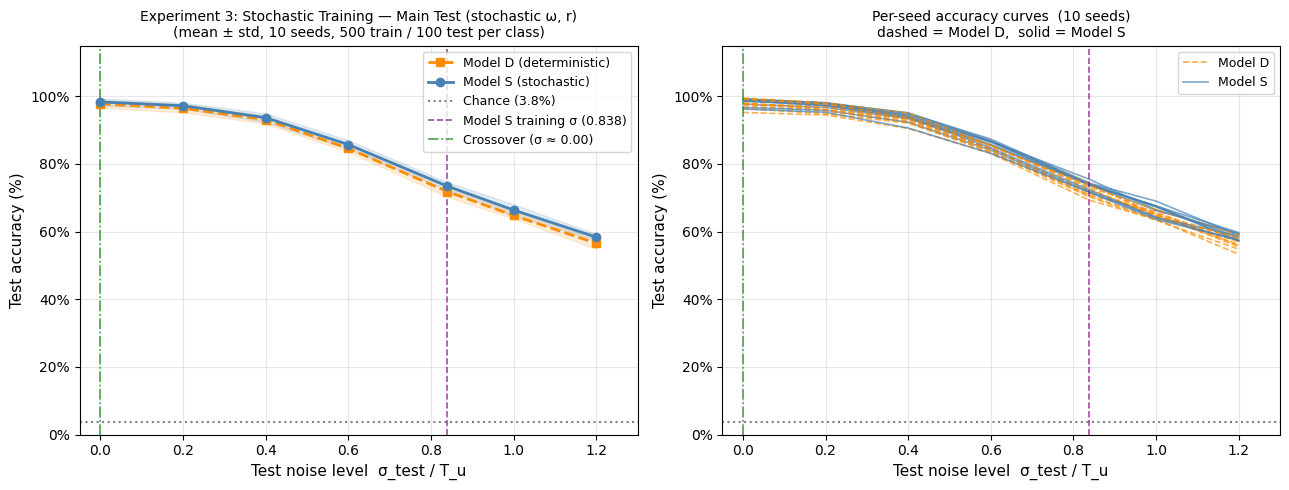

Saved -> exp3_stochastic_robustness.pdf


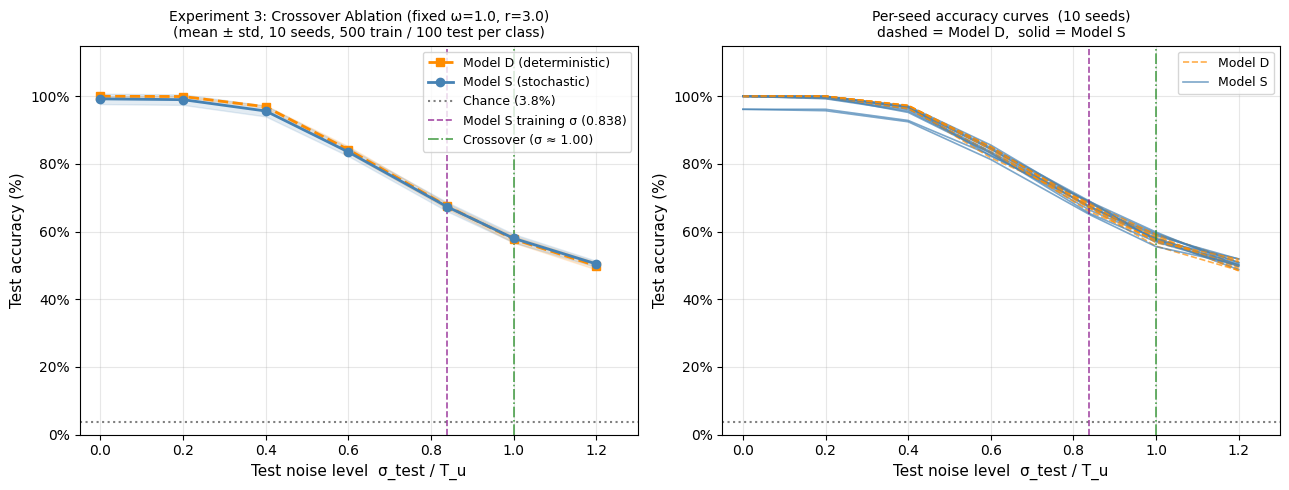

Saved -> exp3_crossover_ablation.pdf


In [10]:
import matplotlib.ticker as mticker

sigma_x = np.array(SIGMA_TEST_FRACS)
chance  = 100.0 / N_CLASSES   # 3.85%


def make_figure(results, title_main, fname):
    """Produce a 2-panel robustness figure for one result set."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left panel: mean ± std ────────────────────────────────────────────
    ax = axes[0]
    for model_key, label, color, ls, mkr in [
        ('D', 'Model D (deterministic)', 'darkorange', '--', 's'),
        ('S', 'Model S (stochastic)',    'steelblue',  '-',  'o'),
    ]:
        means = np.array([
            np.mean([r[model_key][sf] * 100 for r in results])
            for sf in SIGMA_TEST_FRACS
        ])
        stds = np.array([
            np.std([r[model_key][sf] * 100 for r in results])
            for sf in SIGMA_TEST_FRACS
        ])
        ax.plot(sigma_x, means, ls=ls, color=color, lw=2.0,
                marker=mkr, ms=6, label=label, zorder=4)
        ax.fill_between(sigma_x, means - stds, means + stds,
                        color=color, alpha=0.15, zorder=3)

    ax.axhline(chance, ls=':', color='gray', lw=1.5,
               label=f'Chance ({chance:.1f}%)', zorder=2)
    ax.axvline(SIGMA_FRAC_TRAIN, ls='--', color='purple', lw=1.2, alpha=0.7,
               label=f'Model S training σ ({SIGMA_FRAC_TRAIN})', zorder=2)

    _means_D = np.array([np.mean([r['D'][sf] * 100 for r in results])
                         for sf in SIGMA_TEST_FRACS])
    _means_S = np.array([np.mean([r['S'][sf] * 100 for r in results])
                         for sf in SIGMA_TEST_FRACS])
    _cx_mask = _means_S >= _means_D
    if _cx_mask.any():
        _cx_frac = sigma_x[int(np.where(_cx_mask)[0][0])]
        ax.axvline(_cx_frac, ls='-.', color='forestgreen', lw=1.2, alpha=0.8,
                   label=f'Crossover (σ ≈ {_cx_frac:.2f})', zorder=2)

    ax.set_xlabel('Test noise level  σ_test / T_u', fontsize=11)
    ax.set_ylabel('Test accuracy (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_xlim(-0.05, 1.30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(
        f'{title_main}\n'
        f'(mean ± std, {N_SEEDS} seeds, {N_TRAIN} train / {N_TEST} test per class)',
        fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, zorder=0)

    # ── Right panel: per-seed curves ──────────────────────────────────────
    ax = axes[1]
    for si, result in enumerate(results):
        accs_D = [result['D'][sf] * 100 for sf in SIGMA_TEST_FRACS]
        accs_S = [result['S'][sf] * 100 for sf in SIGMA_TEST_FRACS]
        ax.plot(sigma_x, accs_D, '--', color='darkorange', lw=1.2, alpha=0.7,
                label='Model D' if si == 0 else '_')
        ax.plot(sigma_x, accs_S, '-',  color='steelblue',  lw=1.2, alpha=0.7,
                label='Model S' if si == 0 else '_')

    ax.axhline(chance, ls=':', color='gray', lw=1.5)
    ax.axvline(SIGMA_FRAC_TRAIN, ls='--', color='purple', lw=1.2, alpha=0.7)
    if _cx_mask.any():
        ax.axvline(_cx_frac, ls='-.', color='forestgreen', lw=1.2, alpha=0.8)

    ax.set_xlabel('Test noise level  σ_test / T_u', fontsize=11)
    ax.set_ylabel('Test accuracy (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_xlim(-0.05, 1.30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(
        f'Per-seed accuracy curves  ({N_SEEDS} seeds)\n'
        'dashed = Model D,  solid = Model S',
        fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, zorder=0)

    fig.tight_layout()
    fig.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {fname}')


make_figure(
    all_results,
    'Experiment 3: Stochastic Training — Main Test (stochastic ω, r)',
    'exp3_stochastic_robustness.pdf',
)

make_figure(
    all_results_fixed,
    'Experiment 3: Crossover Ablation (fixed ω=1.0, r=3.0)',
    'exp3_crossover_ablation.pdf',
)

## Summary

### Success criteria for Experiment 3

| Criterion | Target | Rationale |
|-----------|--------|----------|
| Model D train accuracy | ≥ 90% | Ideal Morse is easy; should converge cleanly |
| Model S test at σ = 0.84 | ≥ 65% | Matches training conditions (cf. Exp2 intact ~74%) |
| Crossover exists | σ_cross ≤ 1.20 | Model S must eventually outperform Model D |
| Model S at σ = 1.20 | > chance (3.85%) | Graceful degradation |
| Model D at σ = 1.20 | < Model S | D degrades faster than S |

### After running

Update `notebooks/exp3_analysis.md` with the run results.


In [11]:
print('=' * 64)
print('Experiment 3 -- Stochastic Training and Temporal Robustness')
print('=' * 64)
print()
print(f'Protocol:  WPM={WPM}, T_u={T_U:.0f} ms')
print(f'Model D:   sigma=0, omega=1.0, r=3.0  (deterministic ideal Morse)')
print(f'Model S:   sigma={SIGMA_FRAC_TRAIN}*T_u, omega~U[{OMEGA_LO},{OMEGA_HI}], r~U[{R_LO},{R_HI}]  (full TEMPO v1.1)')
print(f'Test:      sigma_test in {SIGMA_TEST_FRACS} x T_u')
print(f'           Main:     omega and r stochastic for all test conditions')
print(f'           Ablation: omega=1.0, r=3.0 fixed (isolates jitter contribution)')
print()

# ── Helper: print results table + stats ───────────────────────────────────
def print_results_block(results, label):
    print(f'--- {label} ---')
    print('Results (mean +/- std over seeds):')
    print(f'{"sigma/T_u":>9} | {"Model D":>12} | {"Model S":>12} | {"delta(S-D)":>11}')
    print('-' * 52)
    for sigma_frac in SIGMA_TEST_FRACS:
        accs_D = [r['D'][sigma_frac] * 100 for r in results]
        accs_S = [r['S'][sigma_frac] * 100 for r in results]
        m_D, s_D = np.mean(accs_D), np.std(accs_D)
        m_S, s_S = np.mean(accs_S), np.std(accs_S)
        delta = m_S - m_D
        flag = '  <-- S leads' if delta > 0 else '  <-- D leads'
        print(f'{sigma_frac:>9.2f} | {m_D:>5.1f}+/-{s_D:.1f}% | '
              f'{m_S:>5.1f}+/-{s_S:.1f}% | {delta:>+9.1f} pp{flag}')
    print()

    n_seeds = len(results)
    df_t = n_seeds - 1
    print(f'Statistical tests (one-tailed paired t-test, n={n_seeds} seeds):')
    sig_levels = []
    for sigma in SIGMA_TEST_FRACS:
        s_vals = [r['S'][sigma] * 100 for r in results]
        d_vals = [r['D'][sigma] * 100 for r in results]
        mu, sd, t, p = paired_t_test(s_vals, d_vals)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  sigma={sigma:.2f}: delta={mu:+.2f}pp  t({df_t})={t:.3f}  p={p:.4f}  {sig}')
        sig_levels.append((sigma, p))
    n_sig = sum(1 for _, p in sig_levels if p < 0.05)
    p_sign = 0.5 ** len(SIGMA_TEST_FRACS)
    print(f'\nSignificant at p<0.05: {n_sig}/{len(SIGMA_TEST_FRACS)} noise levels')
    print(f'Sign test (S>D at all {len(SIGMA_TEST_FRACS)} levels): p = {p_sign:.4f}')
    print()

print_results_block(all_results,       'Main test  (stochastic omega, r)')
print_results_block(all_results_fixed, 'Crossover ablation  (fixed omega=1.0, r=3.0)')

# ── Success criteria (checked against main test) ──────────────────────────
print('Success criteria (main test):')

d_train_accs = [r['D_train_acc'] * 100 for r in all_results]
mean_d_train = np.mean(d_train_accs)
c1 = 'PASS' if mean_d_train >= 90 else 'FAIL'
print(f'  Model D train acc >= 90%             : {c1}  ({mean_d_train:.1f}%)')

proto_frac = 0.84
if proto_frac in SIGMA_TEST_FRACS:
    s_proto_accs = [r['S'][proto_frac] * 100 for r in all_results]
    mean_s_proto = np.mean(s_proto_accs)
    c2 = 'PASS' if mean_s_proto >= 65 else 'FAIL'
    print(f'  Model S acc at sigma=0.84 >= 65%    : {c2}  ({mean_s_proto:.1f}%)')

s_hi_accs = [r['S'][1.20] * 100 for r in all_results]
mean_s_hi = np.mean(s_hi_accs)
c4 = 'PASS' if mean_s_hi > (100/N_CLASSES) else 'FAIL'
print(f'  Model S acc at sigma=1.20 > chance   : {c4}  ({mean_s_hi:.1f}% > {100/N_CLASSES:.1f}%)')

d_hi_accs = [r['D'][1.20] * 100 for r in all_results]
mean_d_hi = np.mean(d_hi_accs)
c5 = 'PASS' if mean_d_hi < mean_s_hi else 'FAIL'
print(f'  Model D acc at sigma=1.20 < Model S  : {c5}  (D={mean_d_hi:.1f}%, S={mean_s_hi:.1f}%)')

# Crossover in ablation
_means_D = np.array([np.mean([r['D'][sf]*100 for r in all_results_fixed]) for sf in SIGMA_TEST_FRACS])
_means_S = np.array([np.mean([r['S'][sf]*100 for r in all_results_fixed]) for sf in SIGMA_TEST_FRACS])
_cx_mask = _means_S >= _means_D
c3 = 'PASS' if _cx_mask.any() else 'FAIL'
cx_str = f'at sigma={SIGMA_TEST_FRACS[int(np.where(_cx_mask)[0][0])]:.2f}' if _cx_mask.any() else 'not found'
print(f'  Crossover (ablation: S >= D) exists  : {c3}  ({cx_str})')

print()
print('Figures saved to:')
print('  exp3_stochastic_robustness.pdf')
print('  exp3_crossover_ablation.pdf')

Experiment 3 -- Stochastic Training and Temporal Robustness

Protocol:  WPM=20, T_u=60 ms
Model D:   sigma=0, omega=1.0, r=3.0  (deterministic ideal Morse)
Model S:   sigma=0.838*T_u, omega~U[0.8,1.3], r~U[2.5,4.5]  (full TEMPO v1.1)
Test:      sigma_test in [0.0, 0.2, 0.4, 0.6, 0.84, 1.0, 1.2] x T_u
           Main:     omega and r stochastic for all test conditions
           Ablation: omega=1.0, r=3.0 fixed (isolates jitter contribution)

--- Main test  (stochastic omega, r) ---
Results (mean +/- std over seeds):
sigma/T_u |      Model D |      Model S |  delta(S-D)
----------------------------------------------------
     0.00 |  97.7+/-1.2% |  98.3+/-1.0% |      +0.6 pp  <-- S leads
     0.20 |  96.5+/-1.2% |  97.2+/-0.9% |      +0.8 pp  <-- S leads
     0.40 |  93.1+/-1.2% |  93.7+/-1.3% |      +0.6 pp  <-- S leads
     0.60 |  84.6+/-1.0% |  85.7+/-1.3% |      +1.1 pp  <-- S leads
     0.84 |  71.8+/-1.5% |  73.4+/-1.2% |      +1.6 pp  <-- S leads
     1.00 |  64.8+/-1.0% |  66.